# Pràctica 1: Identificació d'Idioma
## Fase 0 — Configuració i Exploració del Corpus

In [1]:
# Imports i configuració global
import os
import re
import math
import collections
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              classification_report, ConfusionMatrixDisplay)
import nltk
from nltk.collocations import (BigramCollocationFinder,
                                TrigramCollocationFinder,
                                QuadgramCollocationFinder)

# Constants del projecte
LANGUAGES  = ['deu', 'eng', 'spa', 'fra', 'ita', 'nld']
TRAIN_SIZE = 30_000
TEST_SIZE  = 10_000
DATA_DIR   = Path("langId")


### Exploració del format dels fitxers

In [2]:
sample_file = DATA_DIR / 'eng_trn.txt'
with open(sample_file, 'r', encoding='utf-8') as f:
    for i, line in enumerate(f):
        print(repr(line))
        if i >= 4:
            break


'1\t• • •\n'
'2\t0.00 0.00% How the mighty have fallen.\n'
"3\t0.00 0.00% Major companies coming out with their latest quarterly numbers include Dave & Buster's, Men's Wearhouse, Palo Alto Networks, Box, Barnes & Noble, Pep Boys-Manny, Moe & Jack, Ollie's Bargain Outlet, DavidsTea, Lululemon Athletica and Kroger.\n"
'4\t01 JANUARY 2015, MAGAZINE Why are there so many Magna Cartas?\n'
'5\t0:44 Now watching Up next 2016 Word Association with Brad Woodhouse The president of the Democratic American Bridge PAC on the GOP presidential field.\n'


### Càrrega completa del corpus

In [3]:
def load_corpus(filepath: str) -> list[str]:
    """
    Llegeix un fitxer del corpus Leipzig.
    Format: <id>\t<text>\n
    Retorna una llista de strings (frases netes).
    """
    sentences = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split('\t')
            text = parts[-1] if len(parts) > 1 else parts[0]
            if text:
                sentences.append(text)
    return sentences


corpus = {}   # corpus[lang]['train'] / ['test']
for lang in LANGUAGES:
    corpus[lang] = {
        'train': load_corpus(DATA_DIR / f'{lang}_trn.txt'),
        'test':  load_corpus(DATA_DIR / f'{lang}_tst.txt'),
    }


### Inspecció estadística del corpus

In [4]:
print(f"{'Lang':<6} {'Train':>8} {'Test':>8} {'Avg len train':>15} {'Avg len test':>14}")
print("-" * 55)
for lang in LANGUAGES:
    tr = corpus[lang]['train']
    ts = corpus[lang]['test']
    print(f"{lang:<6} {len(tr):>8,} {len(ts):>8,} "
          f"{sum(len(s) for s in tr)/len(tr):>14.1f} "
          f"{sum(len(s) for s in ts)/len(ts):>13.1f}")

print("\nMostres de frases:")
for lang in LANGUAGES:
    print(f"\n[{lang.upper()}]")
    for s in corpus[lang]['train'][:2]:
        print(f"  {s}")


Lang      Train     Test   Avg len train   Avg len test
-------------------------------------------------------
deu      29,928    9,990          113.0         113.0
eng      29,935    9,987          120.8         120.0
spa      30,000   10,000          131.5         131.9
fra      30,000   10,000          122.7         123.1
ita      30,000   10,000          127.0         127.1
nld      30,000   10,000          106.0         106.1

Mostres de frases:

[DEU]
  04.01.15 Wissenschaft Welche Rolle das Licht im Wissenschaftsjahr 2015 in Jena spielt Weltweit wird 2015 dem Thema Licht große Aufmerksamkeit gewidmet.
  04.04.2014 – 09:54Touristik "Das Magazin für die Freiheit unterwegs": AUTO BILD launcht neue Zeitschrift REISEMOBIL Hamburg (ots) - Die Deutschen sind Reiseweltmeister - auch auf vier Rädern im rollenden Appartement.

[ENG]
  • • •
  0.00 0.00% How the mighty have fallen.

[SPA]
  Denuncia IEM probable fraude con actas electorales El Instituto Electoral de Michoacán denunció ant

## Fase 1 — Preprocessament del Text

In [5]:
def preprocess(sentences: list[str]) -> str:
    """
    Pipeline de preprocessament per al corpus d'entrenament:
      1. Eliminar dígits
      2. Convertir a minúscules
      3. Substituir espais múltiples per un de sol
      4. Concatenar totes les frases amb DOBLE espai (frontera de frase)
    Retorna un únic string amb tot el corpus preprocessat.
    """
    processed = []
    for sent in sentences:
        s = re.sub(r'\d', '', sent)   # 1. Eliminar dígits
        s = s.lower()                  # 2. Minúscules
        s = re.sub(r' +', ' ', s)      # 3. Espais múltiples → un sol espai
        s = s.strip()
        if s:
            processed.append(s)
    return '  '.join(processed)        # 4. Doble espai entre frases


### Aplicació i verificació del preprocessament

In [6]:
corpus_prep = {}   # corpus_prep[lang]['train']  (string únic concatenat)
for lang in LANGUAGES:
    corpus_prep[lang] = {
        'train': preprocess(corpus[lang]['train']),
    }

print("Verificació (primers 200 caràcters de train):\n")
for lang in LANGUAGES:
    print(f"[{lang.upper()}] {corpus_prep[lang]['train'][:200]}")
    print()


Verificació (primers 200 caràcters de train):

[DEU] .. wissenschaft welche rolle das licht im wissenschaftsjahr in jena spielt weltweit wird dem thema licht große aufmerksamkeit gewidmet.  .. – :touristik "das magazin für die freiheit unterwegs": auto 

[ENG] • • •  . .% how the mighty have fallen.  . .% major companies coming out with their latest quarterly numbers include dave & buster's, men's wearhouse, palo alto networks, box, barnes & noble, pep boys

[SPA] denuncia iem probable fraude con actas electorales el instituto electoral de michoacán denunció ante la fiscalía especializada la presencia de actas de escrutinio y cómputo, al parecer apócrifas, en u

[FRA] le président de l'om, jean-claude dassier, y confirme à son homologue toulousain, olivier sadran, "l'intérêt de l'olympique de marseille à faire venir le joueur andré-pierre gignac".  il a signé jeudi

[ITA] "ora questa squadra può fare il salto di qualità".  il kaiser di kerpen, che dovrebbe tornare in pista mercoledì pe

### Estadístiques post-preprocessament

In [7]:
print(f"{'Lang':<6} {'Chars train':>12}")
print("-" * 20)
for lang in LANGUAGES:
    print(f"{lang:<6} {len(corpus_prep[lang]['train']):>12,}")


Lang    Chars train
--------------------
deu       3,405,314
eng       3,635,844
spa       3,965,103
fra       3,698,635
ita       3,830,306
nld       3,173,458


## Fase 2 — Construcció dels Models de Llengua

In [8]:
# Paràmetres globals del model final
N_GRAM   = 3    # Ordre del model
LAMBDA   = 0.5  # Suavitzat de Lidstone (λ)
MIN_FREQ = 5    # Freqüència mínima per filtrar n-grames

FINDER = {2: BigramCollocationFinder,
          3: TrigramCollocationFinder,
          4: QuadgramCollocationFinder}[N_GRAM]

print(f"Configuració del model: n={N_GRAM}, λ={LAMBDA}, min_freq={MIN_FREQ}")


Configuració del model: n=3, λ=0.5, min_freq=5


### Extracció de n-grames filtrats (dataset net)

In [9]:
def get_ngram_counts(text: str, finder_cls, min_freq: int) -> collections.Counter:
    """
    Extreu n-grames de caràcters, aplica filtre de freqüència mínima
    i retorna un Counter (dataset net definitiu).
    """
    finder = finder_cls.from_words(text)
    finder.apply_freq_filter(min_freq)
    return collections.Counter(dict(finder.ngram_fd))


raw_counts = {}
for lang in LANGUAGES:
    raw_counts[lang] = get_ngram_counts(
        corpus_prep[lang]['train'], FINDER, MIN_FREQ)
    print(f"[{lang.upper()}] n-grames únics (freq≥{MIN_FREQ}): "
          f"{len(raw_counts[lang]):>8,}")


[DEU] n-grames únics (freq≥5):   11,321
[ENG] n-grames únics (freq≥5):    9,392
[SPA] n-grames únics (freq≥5):    9,294
[FRA] n-grames únics (freq≥5):   10,600
[ITA] n-grames únics (freq≥5):    8,339
[NLD] n-grames únics (freq≥5):   10,148


### Càlcul de N i B sobre el dataset net

In [10]:
# N per idioma = total d'ocurrències al dataset net
N = {}
for lang in LANGUAGES:
    N[lang] = sum(raw_counts[lang].values())
    print(f"[{lang.upper()}] N (ocurrències al model): {N[lang]:>12,}")

print()

# B global = unió dels n-grames únics de TOTS els models nets
all_ngrams = set()
for lang in LANGUAGES:
    all_ngrams.update(raw_counts[lang].keys())

B = len(all_ngrams)
print(f"B global (unió de tots els models nets): {B:,} n-grames únics")


[DEU] N (ocurrències al model):    3,387,083
[ENG] N (ocurrències al model):    3,621,034
[SPA] N (ocurrències al model):    3,947,903
[FRA] N (ocurrències al model):    3,680,862
[ITA] N (ocurrències al model):    3,813,560
[NLD] N (ocurrències al model):    3,154,095

B global (unió de tots els models nets): 21,968 n-grames únics


### Construcció dels models finals (log-probabilitats de Lidstone)

In [11]:
def build_model(counts: collections.Counter,
                n_total: int,
                b: int,
                lam: float = LAMBDA) -> dict:
    """
    Construeix el model de llengua amb suavitzat de Lidstone.

    counts  : n-grames nets {ngram: freq}
    n_total : suma total d'ocurrències al dataset net (N)
    b       : unió global de n-grames nets (B)
    lam     : paràmetre λ de Lidstone

    Retorna:
        'probs'      -> {ngram: log_prob} per als n-grames del model
        'log_unseen' -> log_prob per a qualsevol n-grama fora del model
    """
    denom       = n_total + lam * b
    log_unseen  = math.log(lam / denom)
    probs       = {ng: math.log((c + lam) / denom)
                   for ng, c in counts.items()}
    return {'probs': probs, 'log_unseen': log_unseen}


models = {}
for lang in LANGUAGES:
    models[lang] = build_model(raw_counts[lang], N[lang], B)
    print(f"[{lang.upper()}] log_unseen = {models[lang]['log_unseen']:.4f}"
          f" | n-grames al model: {len(models[lang]['probs']):>8,}")

print()
print(f"Top-5 n-grames més probables per idioma (n={N_GRAM}):")
for lang in LANGUAGES:
    top5 = sorted(models[lang]['probs'].items(),
                  key=lambda x: x[1], reverse=True)[:5]
    print(f"  [{lang.upper()}] {', '.join(''.join(t) for t, _ in top5)}")


[DEU] log_unseen = -15.7319 | n-grames al model:   11,321
[ENG] log_unseen = -15.7984 | n-grames al model:    9,392
[SPA] log_unseen = -15.8846 | n-grames al model:    9,294
[FRA] log_unseen = -15.8148 | n-grames al model:   10,600
[ITA] log_unseen = -15.8501 | n-grames al model:    8,339
[NLD] log_unseen = -15.6608 | n-grames al model:   10,148

Top-5 n-grames més probables per idioma (n=3):
  [DEU] en , er ,  de, .  , der
  [ENG]  th, the, he , .  , ing
  [SPA]  de, de , os ,  la, el 
  [FRA]  de, es , de ,  le, .  
  [ITA]  di, to , .  ,  de, la 
  [NLD] en , de ,  de, .  , an 


## Fase 3 — Classificador (Inferència)

In [12]:
def score_text(text: str, model: dict, finder_cls) -> float:
    """
    Calcula el log-score d'un text preprocessat donat un model de llengua.
    Suma les log-probabilitats de TOTS els n-grames amb repetició:

        log P(d) = sum_j log P(e_j)

    on j recorre tots els n-grames del text, comptant repeticions.
    """
    finder = finder_cls.from_words(text)
    if not finder.ngram_fd:
        return float('-inf')
    return sum(
        count * model['probs'].get(ng, model['log_unseen'])
        for ng, count in finder.ngram_fd.items()
    )


def classify(sentence: str, models: dict, finder_cls) -> str:
    """Classifica una frase preprocessada retornant l'idioma més probable."""
    scores = {lang: score_text(sentence, models[lang], finder_cls)
              for lang in models}
    return max(scores, key=scores.get)


### Preprocessament del test set i classificació

In [13]:
def preprocess_single(sentence: str) -> str:
    """
    Mateixa pipeline que preprocess() però per a una sola frase
    (sense concatenació).
    """
    s = re.sub(r'\d', '', sentence)
    s = s.lower()
    s = re.sub(r' +', ' ', s).strip()
    return s


# Construïm all_results: llista de dicts amb tota la informació per frase.
# Aquesta és l'ÚNICA classificació que es fa al notebook.
# Totes les fases posteriors reutilitzen aquesta estructura.
all_results = []

for lang in LANGUAGES:
    for orig in corpus[lang]['test']:
        prep = preprocess_single(orig)
        if not prep:        # descartem frases que queden buides
            continue
        pred = classify(prep, models, FINDER)
        all_results.append({
            'true': lang,
            'orig': orig,
            'prep': prep,
            'pred': pred,
            'ok':   pred == lang,
            'len':  len(prep),   # longitud post-preprocessament (per Exp. C)
        })

# y_true i y_pred derivats directament d'all_results
y_true = [r['true'] for r in all_results]
y_pred = [r['pred'] for r in all_results]

print(f"Total frases classificades: {len(all_results):,}")
for lang in LANGUAGES:
    n = sum(1 for r in all_results if r['true'] == lang)
    print(f"  [{lang.upper()}]  {n:,} frases")


Total frases classificades: 59,977
  [DEU]  9,990 frases
  [ENG]  9,987 frases
  [SPA]  10,000 frases
  [FRA]  10,000 frases
  [ITA]  10,000 frases
  [NLD]  10,000 frases


### Validació del classificador amb exemples manuals

In [14]:
print("Validació manual del classificador:\n")
for lang in LANGUAGES:
    mostres = [r for r in all_results if r['true'] == lang][:3]
    print(f"[{lang.upper()}]")
    for r in mostres:
        ok = "Classificació correcta" if r['ok'] else f"Error (prediu {r['pred'].upper()})"
        print(f"  {ok}  {r['prep'][:80]}")
    print()


Validació manual del classificador:

[DEU]
  Classificació correcta  : dgap-adhoc: accu holding ag: einladung zur generalversammlung und ernennung ei
  Classificació correcta  .. – : min mediathek familiennachzug von flüchtlingen de-maizière-vorstoß entzwe
  Classificació correcta  day-exploits werden auf dem ohnehin bereits von konkurrierenden geheimdiensten f

[ENG]
  Classificació correcta  : autoplay autoplay copy this code to your website or blog moscow — timur the go
  Classificació correcta  : gmt - roadmap signed - the head of the un atomic watchdog says iran has signed
  Classificació correcta  moments from the iraq war photos a boy stands at the scene of a car bombing in f

[SPA]
  Classificació correcta  denuncia iem probable fraude con actas electorales el instituto electoral de mic
  Classificació correcta  a pesar de la organización del movimiento, su paisano, abelande, critica la disp
  Classificació correcta  es decir, el bm entrega préstamos (evidentemente con elevados

## Fase 4 — Avaluació

### Accuracy global

In [15]:
acc = accuracy_score(y_true, y_pred)
print(f"Accuracy global: {acc:.4f} ({acc*100:.2f}%)")

Accuracy global: 0.9988 (99.88%)


### Matriu de confusió

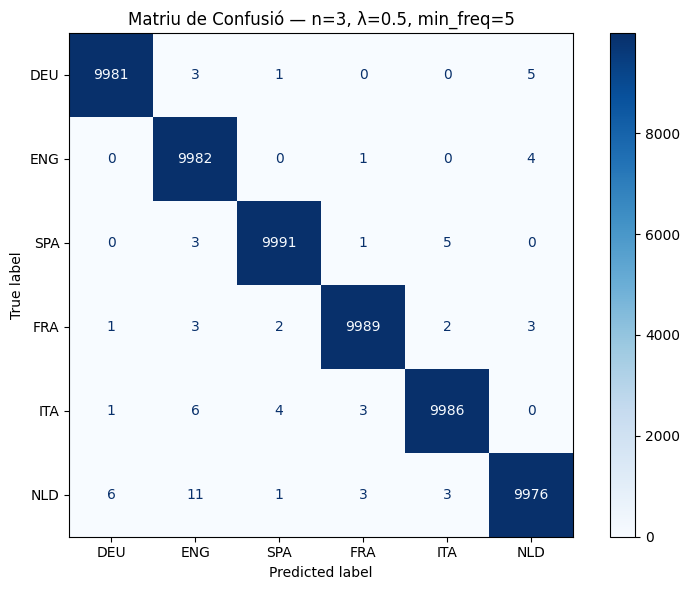

In [16]:
cm = confusion_matrix(y_true, y_pred, labels=LANGUAGES)

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(cm, display_labels=[l.upper() for l in LANGUAGES])\
    .plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title(f"Matriu de Confusió — n={N_GRAM}, λ={LAMBDA}, min_freq={MIN_FREQ}")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

### Report per idioma

In [17]:
print(classification_report(
    y_true, y_pred,
    labels=LANGUAGES,
    target_names=[l.upper() for l in LANGUAGES],
    digits=4
))

              precision    recall  f1-score   support

         DEU     0.9992    0.9991    0.9991      9990
         ENG     0.9974    0.9995    0.9984      9987
         SPA     0.9992    0.9991    0.9991     10000
         FRA     0.9992    0.9989    0.9990     10000
         ITA     0.9990    0.9986    0.9988     10000
         NLD     0.9988    0.9976    0.9982     10000

    accuracy                         0.9988     59977
   macro avg     0.9988    0.9988    0.9988     59977
weighted avg     0.9988    0.9988    0.9988     59977



## Fase 5 — Experiments

In [18]:
def run_experiment(n_gram: int, lam: float,
                   corpus_prep: dict, all_res: list,
                   languages: list, min_freq: int = MIN_FREQ) -> dict:
    """
    Pipeline completa per a uns paràmetres donats (n, lambda).
    Construeix models nous i avalua sobre les frases preprocessades d'all_res.
    Retorna accuracy, y_true i y_pred.
    """
    finder_cls = {2: BigramCollocationFinder,
                  3: TrigramCollocationFinder,
                  4: QuadgramCollocationFinder}[n_gram]

    rc = {lang: get_ngram_counts(corpus_prep[lang]['train'],
                                 finder_cls, min_freq)
          for lang in languages}

    b       = len(set().union(*[set(rc[l].keys()) for l in languages]))
    n_total = {lang: sum(rc[lang].values()) for lang in languages}

    mdls = {lang: build_model(rc[lang], n_total[lang], b, lam)
            for lang in languages}

    # Reutilitzem les frases preprocessades d'all_res (sense reclassificar)
    yt, yp = [], []
    for r in all_res:
        yt.append(r['true'])
        yp.append(classify(r['prep'], mdls, finder_cls))

    return {
        'n': n_gram, 'lambda': lam,
        'accuracy': accuracy_score(yt, yp),
        'y_true': yt, 'y_pred': yp
    }


### Experiment A — Impacte de l'ordre n (λ = 0.5 fix)

In [19]:
print("Experiment A: Impacte de n\n")
print(f"{'n':>4} {'Accuracy':>10} {'Errors':>8}")
print("-" * 28)

results_n = []
for n in [2, 3, 4]:
    res = run_experiment(n, 0.5, corpus_prep, all_results, LANGUAGES)
    results_n.append(res)
    errors = sum(1 for t, p in zip(res['y_true'], res['y_pred']) if t != p)
    print(f"{n:>4} {res['accuracy']:>10.4f} {errors:>8,}")


Experiment A: Impacte de n

   n   Accuracy   Errors
----------------------------
   2     0.9945      332
   3     0.9988       72
   4     0.9996       22


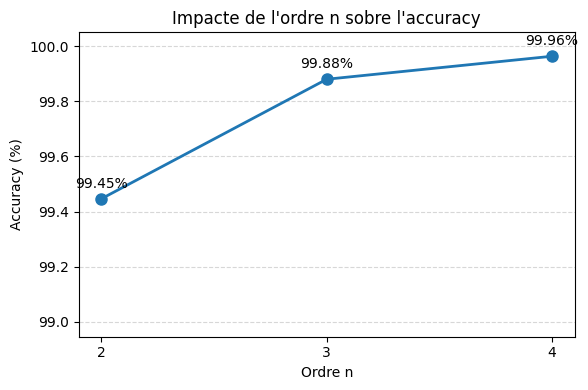

In [20]:
fig, ax = plt.subplots(figsize=(6, 4))
ns    = [r['n'] for r in results_n]
accs  = [r['accuracy'] * 100 for r in results_n]
ax.plot(ns, accs, marker='o', linewidth=2, markersize=8)
ax.set_xlabel("Ordre n")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Impacte de l'ordre n sobre l'accuracy")
ax.set_xticks(ns)
ax.set_ylim(min(accs) - 0.5, 100.05)
for x, y in zip(ns, accs):
    ax.annotate(f"{y:.2f}%", (x, y), textcoords="offset points",
                xytext=(0, 8), ha='center', fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("exp_a_n.png", dpi=150)
plt.show()

### Experiment B — Impacte de λ (n = 3 fix)

In [22]:
print("\nExperiment B: Impacte de λ\n")
print(f"{'λ':>6} {'Accuracy':>10} {'Errors':>8}")
print("-" * 30)

lambdas    = [round(x, 2) for x in np.linspace(0.1, 1.0, 7)]
results_lam = []
for lam in lambdas:
    res = run_experiment(3, lam, corpus_prep, all_results, LANGUAGES)
    results_lam.append(res)
    errors = sum(1 for t, p in zip(res['y_true'], res['y_pred']) if t != p)
    print(f"{lam:>6.2f} {res['accuracy']:>10.4f} {errors:>8,}")



Experiment B: Impacte de λ

     λ   Accuracy   Errors
------------------------------
  0.10     0.9987       79
  0.25     0.9987       76
  0.40     0.9988       74
  0.55     0.9988       72
  0.70     0.9988       71
  0.85     0.9988       72
  1.00     0.9988       71


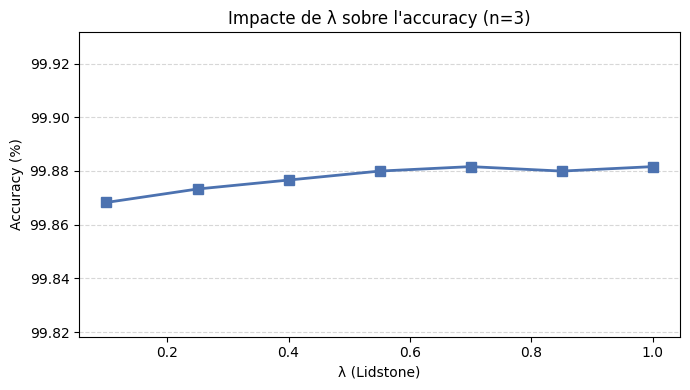

In [23]:
fig, ax = plt.subplots(figsize=(7, 4))
lams  = [r['lambda'] for r in results_lam]
accs  = [r['accuracy'] * 100 for r in results_lam]
ax.plot(lams, accs, marker='s', linewidth=2, markersize=7, color='#4C72B0')
ax.set_xlabel("λ (Lidstone)")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Impacte de λ sobre l'accuracy (n=3)")
ax.set_ylim(min(accs) - 0.05, max(accs) + 0.05)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("exp_b_lambda.png", dpi=150)
plt.show()

### Experiment C — Accuracy per franja de longitud de frase

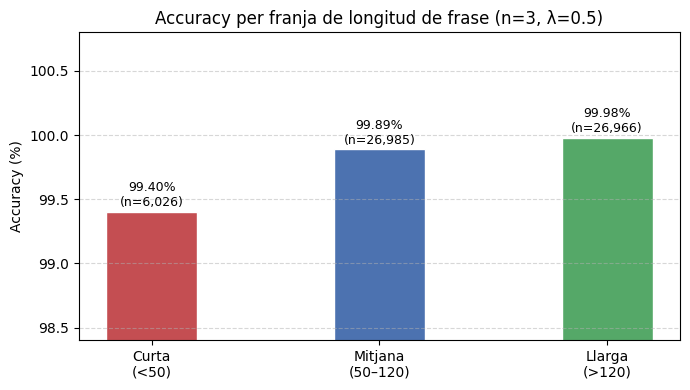

In [24]:
BINS       = [(0, 50), (50, 120), (120, float('inf'))]
BIN_LABELS = ['Curta\n(<50)', 'Mitjana\n(50–120)', 'Llarga\n(>120)']

accs_c   = []
counts_c = []

for (low, high) in BINS:
    franja = [r for r in all_results if low <= r['len'] < high]
    counts_c.append(len(franja))
    accs_c.append(accuracy_score(
        [r['true'] for r in franja],
        [r['pred'] for r in franja]
    ) * 100)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(BIN_LABELS, accs_c,
              color=['#C44E52', '#4C72B0', '#55A868'],
              width=0.4, edgecolor='white')
for bar, acc, n in zip(bars, accs_c, counts_c):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.02,
            f"{acc:.2f}%\n(n={n:,})",
            ha='center', va='bottom', fontsize=9)
ax.set_ylabel("Accuracy (%)")
ax.set_title("Accuracy per franja de longitud de frase (n=3, λ=0.5)")
ax.set_ylim(min(accs_c) - 1, 100.8)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("exp_c_length.png", dpi=150)
plt.show()


## Fase 6 — Anàlisi del Model Final (n=3, λ=0.7)

In [25]:
# Reconstruïm els models amb els paràmetres òptims: n=3, λ=0.7
LAMBDA_OPT = 0.7

models_opt = {}
for lang in LANGUAGES:
    models_opt[lang] = build_model(raw_counts[lang], N[lang], B, lam=LAMBDA_OPT)

# Reclassifiquem tot el test set amb el model òptim
all_results_opt = []
for r in all_results:
    pred_opt = classify(r['prep'], models_opt, FINDER)
    all_results_opt.append({**r, 'pred': pred_opt, 'ok': pred_opt == r['true']})

y_true_opt = [r['true'] for r in all_results_opt]
y_pred_opt = [r['pred'] for r in all_results_opt]

acc_opt = accuracy_score(y_true_opt, y_pred_opt)
errors_opt = sum(1 for r in all_results_opt if not r['ok'])
print(f"Model final: n={N_GRAM}, λ={LAMBDA_OPT}")
print(f"Accuracy   : {acc_opt:.4f} ({acc_opt*100:.2f}%)")
print(f"Errors     : {errors_opt} / {len(all_results_opt):,}")
### Accuracy global del model final
print(classification_report(
    y_true_opt, y_pred_opt,
    labels=LANGUAGES,
    target_names=[l.upper() for l in LANGUAGES],
    digits=4
))

### Matriu de confusió (model final)
cm_opt = confusion_matrix(y_true_opt, y_pred_opt, labels=LANGUAGES)

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(cm_opt, display_labels=[l.upper() for l in LANGUAGES])\
    .plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title(f"Matriu de Confusió — n={N_GRAM}, λ={LAMBDA_OPT}, min_freq={MIN_FREQ}")
plt.tight_layout()
plt.savefig("confusion_matrix_opt.png", dpi=150)
plt.show()


Model final: n=3, λ=0.7
Accuracy   : 0.9988 (99.88%)
Errors     : 71 / 59,977


### Top-10 parells de confusió

In [26]:
errors_list = [(r['true'], r['pred']) for r in all_results_opt if not r['ok']]
print(f"Total errors: {len(errors_list)} / {len(all_results_opt):,} "
      f"({len(errors_list)/len(all_results_opt)*100:.4f}%)\n")

print("Top-10 parells de confusió (veritat → predicció):")
for (true, pred), cnt in collections.Counter(errors_list).most_common(10):
    print(f"  {true.upper()} → {pred.upper()} : {cnt:>5} errors")


Total errors: 71 / 59,977 (0.1184%)

Top-10 parells de confusió (veritat → predicció):
  NLD → ENG :    11 errors
  ITA → ENG :     6 errors
  NLD → DEU :     6 errors
  DEU → NLD :     5 errors
  SPA → ITA :     5 errors
  ENG → NLD :     4 errors
  ITA → SPA :     4 errors
  DEU → ENG :     3 errors
  SPA → ENG :     3 errors
  FRA → NLD :     3 errors


### Inspecció de frases mal classificades

In [28]:
print("Frases mal classificades per idioma:\n")
for lang in LANGUAGES:
    lang_errors = [r for r in all_results_opt if r['true'] == lang and not r['ok']]
    print(f"[{lang.upper()}]  {len(lang_errors)} errors:")
    for r in lang_errors:
        print(f"  → prediu [{r['pred'].upper()}]")
        print(f"     Original : '{r['orig'][:100]}'")
        print(f"     Prep     : '{r['prep'][:100]}'")
    print()


Frases mal classificades per idioma:

[DEU]  9 errors:
  → prediu [SPA]
     Original : 'Autos wie den Dacia Sandero.'
     Prep     : 'autos wie den dacia sandero.'
  → prediu [NLD]
     Original : 'Bildergalerie teilen Der Donkervoort D8 GTO ist ja per se nicht gerade ein Warmduscher-Auto.'
     Prep     : 'bildergalerie teilen der donkervoort d gto ist ja per se nicht gerade ein warmduscher-auto.'
  → prediu [NLD]
     Original : 'Der Stoffbeutel war leer.'
     Prep     : 'der stoffbeutel war leer.'
  → prediu [NLD]
     Original : 'Hij was de leider van de groep in de provincie Khorasan van de Islamitische Staat.'
     Prep     : 'hij was de leider van de groep in de provincie khorasan van de islamitische staat.'
  → prediu [ENG]
     Original : 'Ist das Land bald insolvent?'
     Prep     : 'ist das land bald insolvent?'
  → prediu [ENG]
     Original : 'JarJarThomas 28. Jan 2015 Theorethisch ist es simpel.'
     Prep     : 'jarjarthomas . jan theorethisch ist es simpel.'
  → pre

### Trigrames més discriminatius per idioma

In [29]:
print("Top-10 trigrames més discriminatius per idioma")
print("(major avantatge de log-prob respecte a la mitjana dels altres idiomes):\n")

for lang in LANGUAGES:
    scores = {}
    for ng, lp in models_opt[lang]['probs'].items():
        others = [models_opt[l]['probs'].get(ng, models_opt[l]['log_unseen'])
                  for l in LANGUAGES if l != lang]
        scores[ng] = lp - (sum(others) / len(others))
    top10 = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:10]
    print(f"  [{lang.upper()}]  {'  '.join(repr(''.join(t)) for t, _ in top10)}")


Top-10 trigrames més discriminatius per idioma
(major avantatge de log-prob respecte a la mitjana dels altres idiomes):

  [DEU]  'übe'  'ür '  'zu '  ' üb'  ' fü'  'für'  ' ih'  'ihr'  'tzt'  'nnt'
  [ENG]  '," '  "n't"  'tly'  'whe'  'nly'  "'t "  'who'  'u.s'  'wou'  'yea'
  [SPA]  'ión'  'ció'  'ón '  'más'  ' má'  'ía '  'año'  ' y '  'ría'  'ió '
  [FRA]  ' à '  'e à'  'été'  's à'  't à'  "qu'"  'eux'  'ès '  ' ét'  'prè'
  [ITA]  ' è '  'tà '  'ità'  'rà '  'più'  'iù '  "ll'"  'è s'  'uov'  'o è'
  [NLD]  'ij '  'voo'  'ijn'  'zij'  'jn '  'ijk'  'jke'  'lij'  'jk '  ' oo'


### Solapament de vocabulari entre parells d'idiomes confosos

In [30]:
print("Solapament (Jaccard) entre parells d'idiomes:\n")
print(f"{'Parell':<14}  {'Comuns':>8}  {'Unió':>8}  {'Jaccard':>8}")
print("-" * 44)

pairs = [('deu','nld'), ('spa','ita'), ('fra','spa'),
         ('fra','ita'), ('eng','nld'), ('deu','eng')]
for l1, l2 in pairs:
    s1 = set(models_opt[l1]['probs'].keys())
    s2 = set(models_opt[l2]['probs'].keys())
    inter, union = s1 & s2, s1 | s2
    print(f"{l1.upper()} ↔ {l2.upper()}      "
          f"{len(inter):>8,}  {len(union):>8,}  "
          f"{len(inter)/len(union):>8.4f}")

print("\nTop-10 trigrames més ambigus DEU ↔ NLD "
      "(alta log-prob en tots dos):\n")
shared = {ng: models_opt['deu']['probs'][ng] + models_opt['nld']['probs'][ng]
          for ng in set(models_opt['deu']['probs']) & set(models_opt['nld']['probs'])}
for ng, _ in sorted(shared.items(), key=lambda x: x[1], reverse=True)[:10]:
    print(f"  {''.join(ng)!r:<8}  DEU: {models_opt['deu']['probs'][ng]:.4f}  "
          f"NLD: {models_opt['nld']['probs'][ng]:.4f}")


Solapament (Jaccard) entre parells d'idiomes:

Parell            Comuns      Unió   Jaccard
--------------------------------------------
DEU ↔ NLD         7,494    13,975    0.5362
SPA ↔ ITA         5,807    11,826    0.4910
FRA ↔ SPA         6,136    13,758    0.4460
FRA ↔ ITA         6,250    12,689    0.4926
ENG ↔ NLD         7,093    12,447    0.5699
DEU ↔ ENG         7,039    13,674    0.5148

Top-10 trigrames més ambigus DEU ↔ NLD (alta log-prob en tots dos):

  'en '     DEU: -4.1077  NLD: -3.9009
  ' de'     DEU: -4.7317  NLD: -4.3382
  '.  '     DEU: -4.8169  NLD: -4.6648
  'er '     DEU: -4.3772  NLD: -5.2543
  'n d'     DEU: -5.5994  NLD: -5.0314
  'in '     DEU: -5.4244  NLD: -5.2275
  ' in'     DEU: -5.6515  NLD: -5.1064
  'der'     DEU: -4.9957  NLD: -5.7877
  'ie '     DEU: -5.0251  NLD: -5.8523
  'sch'     DEU: -5.1175  NLD: -5.8457


FALTA PER AFEGIR

- Comparació accuracy amb signes de puntuació vs sense
- Optimització de lambda per idioma

+ REVISAR TOT EL CODI